In [1]:
import numpy as np
import matplotlib.pyplot as plt
from rkhs import RKHS

In [6]:
# Generate synthetic data on the interval [0,1]
# Here we define a smooth function for demonstration purposes.
x = np.linspace(0, 1, 50)
# Example function: f(x) = sin(2πx) + 0.5*cos(3πx)
f_values = np.sin(2 * np.pi * x) + 0.5 * np.cos(3 * np.pi * x)
data_series = np.column_stack((x, f_values))
data_series[:5]

array([[0.        , 0.5       ],
       [0.02040816, 0.61865674],
       [0.04081633, 0.71711296],
       [0.06122449, 0.79431106],
       [0.08163265, 0.84989223]])

In [7]:
# Create an RKHS object with m basis functions and a specified fractal depth.
m = 5
fractal_depth = 2
rkhs_obj = RKHS(data_series=data_series, m=m, fractal_depth=fractal_depth)

Vertical scaling factors s_values were not provided, so they were initialised randomly.
Building the Basis functions for the RKHS:
	Built u_1.
	Built F_[u_1].
	Built u_2.
	Built F_[u_2].
	Built u_3.
	Built F_[u_3].
	Built u_4.
	Built F_[u_4].
	Built u_5.
	Built F_[u_5].
Built matrix A = [<F_[u_i], F_[u_j]>].
Built matrix B = inverse(A).


In [11]:
# Print out the matrix A (inner products) and its inverse B.
print("Matrix A (inner products between fractal basis functions):")
print(rkhs_obj.A)
print("\nMatrix B (inverse of A):")
print(rkhs_obj.B)

Matrix A (inner products between fractal basis functions):
[[ 1.14039257  0.00222457  0.09628426  0.00741135 -0.0173022 ]
 [ 0.00222457  0.50725307  0.02485478  0.00504291  0.00490945]
 [ 0.09628426  0.02485478  1.41836181  0.09221658 -0.04505213]
 [ 0.00741135  0.00504291  0.09221658  0.73219487 -0.08004487]
 [-0.0173022   0.00490945 -0.04505213 -0.08004487  0.97884915]]

Matrix B (inverse of A):
[[ 8.82107980e-01 -1.07961144e-03 -5.94519581e-02 -2.78787922e-05
   1.28590182e-02]
 [-1.07961144e-03  1.97330866e+00 -3.42080695e-02 -1.06228062e-02
  -1.23594003e-02]
 [-5.94519581e-02 -3.42080695e-02  7.16099662e-01 -8.66194328e-02
   2.49963648e-02]
 [-2.78787922e-05 -1.06228062e-02 -8.66194328e-02  1.38872416e+00
   1.09628252e-01]
 [ 1.28590182e-02 -1.23594003e-02  2.49963648e-02  1.09628252e-01
   1.03201242e+00]]


In [12]:
np.linalg.eigvals(rkhs_obj.A)

array([1.46718545, 1.11137997, 0.99177989, 0.70027112, 0.50643503])


Kernel function k(0.9, 0.9) = 3.84206378616929


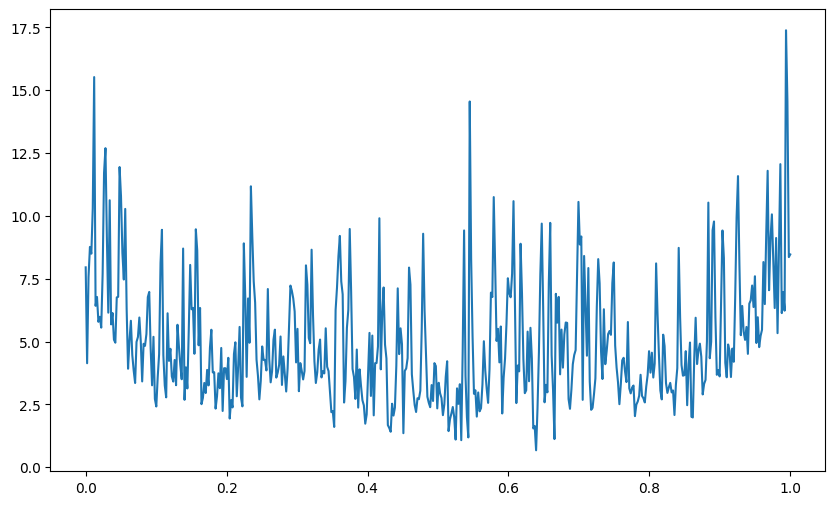

In [9]:
# Evaluate the kernel function between two sample points.
x1 = 0.9
x2 = 0.9
k_val = rkhs_obj.kernel_function(x1, x2)
print(f"\nKernel function k({x1}, {x2}) = {k_val}")
x_plot = np.linspace(0, 1, 500)
plt.figure(figsize=(10, 6))

kf = np.array([rkhs_obj.kernel_function(x,x) for x in x_plot])
# rkhs_obj.kernel_array(x_plot, x_plot)
plt.plot(x_plot, kf)
plt.show()

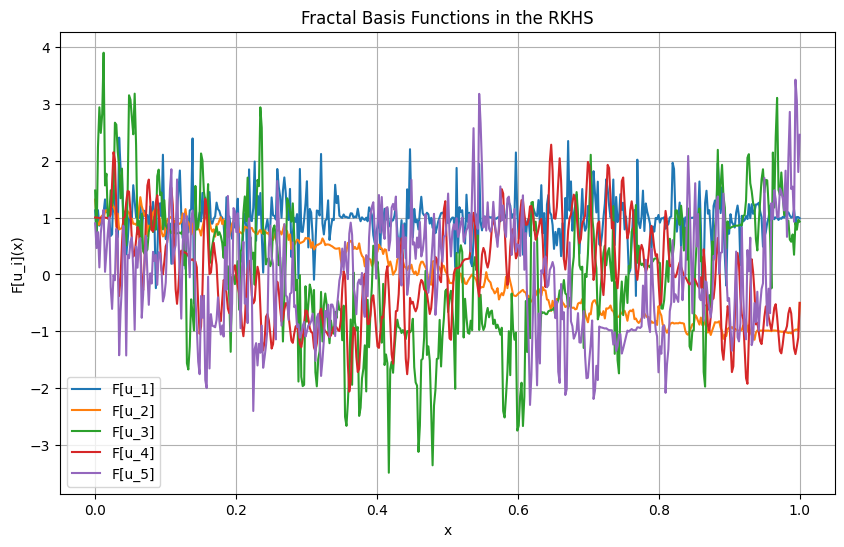

In [7]:
# Plot the fractal basis functions over the interval [0, 1].
x_plot = np.linspace(0, 1, 500)
plt.figure(figsize=(10, 6))
for i in range(1, m+1):
    Fi = rkhs_obj.fractal_basis[f"{i}"]
    y_vals = np.array([Fi(xi) for xi in x_plot])
    plt.plot(x_plot, y_vals, label=f"F[u_{i}]")
plt.title("Fractal Basis Functions in the RKHS")
plt.xlabel("x")
plt.ylabel("F[u_i](x)")
plt.legend()
plt.grid(True)
plt.show()

In [20]:
from scipy.integrate import quad, simpson, trapezoid

tolerances = [1e-3, 1e-6, 1e-8, 1e-10, 1e-12]
print("Convergence test for quad with different tolerances:")
F1 = rkhs_obj.fractal_basis[f"{1}"]
F2 = rkhs_obj.fractal_basis[f"{2}"]
x_points = F1.fractal_points[:, 0] if len(F1.fractal_points[:, 0]) < len(F2.fractal_points[:, 0]) else F2.fractal_points[:, 0]

f1_points = F1(x_points)
f2_points = F2(x_points)
integrand = lambda x: F1(x)*F2(x)
simp_res = simpson(f1_points*f2_points, x=x_points)
print(f"simpson: ", simp_res)
quad_res = quad(integrand, 0, 1, limit=2000)
print(f"quadrature: ", quad_res)

Convergence test for quad with different tolerances:
simpson:  0.0022245704777744263
quadrature:  (0.0011831863249914683, 0.00306749706455595)


C:\Users\adity\AppData\Local\Temp\ipykernel_11768\1438107905.py:14: IntegrationWarning: The maximum number of subdivisions (2000) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.
  quad_res = quad(integrand, 0, 1, limit=2000)


quad (default tolerances):
  Result: 2.0
  Error estimate: 2.220446049250313e-14
  Absolute error: 0.0

quad (tighter tolerances):
  Result: 2.0
  Error estimate: 2.220446049250313e-14
  Absolute error: 0.0

Simpson's rule:
  Result: 2.0
  Absolute error: 0.0

Convergence test for quad with different tolerances:
  Tolerance = 1e-06: Result = 2.0, Error = 2.220446049250313e-14
  Tolerance = 1e-08: Result = 2.0, Error = 2.220446049250313e-14
  Tolerance = 1e-10: Result = 2.0, Error = 2.220446049250313e-14
  Tolerance = 1e-12: Result = 2.0, Error = 2.220446049250313e-14


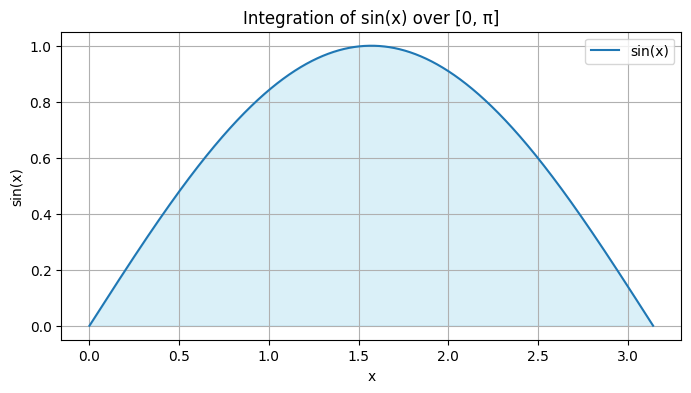

In [ ]:
#!/usr/bin/env python
import numpy as np

import matplotlib.pyplot as plt

def verify_integration():
    # Define a known function, here f(x) = sin(x) with known integral over [0, π] equal to 2.
    f = np.sin
    a, b = 0, np.pi
    expected_value = 2.0

    # 1. Integration using quad with default tolerances.
    res_default, err_default = quad(f, a, b)
    print("quad (default tolerances):")
    print(f"  Result: {res_default}")
    print(f"  Error estimate: {err_default}")
    print(f"  Absolute error: {abs(res_default - expected_value)}\n")

    # 2. Integration using quad with tighter tolerances.
    res_tight, err_tight = quad(f, a, b, epsabs=1e-12, epsrel=1e-12)
    print("quad (tighter tolerances):")
    print(f"  Result: {res_tight}")
    print(f"  Error estimate: {err_tight}")
    print(f"  Absolute error: {abs(res_tight - expected_value)}\n")

    # 3. Integration using Simpson's rule over a fine grid.
    x_grid = np.linspace(a, b, 10001)
    y_vals = f(x_grid)
    res_simps = simps(y_vals, x_grid)
    print("Simpson's rule:")
    print(f"  Result: {res_simps}")
    print(f"  Absolute error: {abs(res_simps - expected_value)}\n")

    # 4. Convergence test: Evaluate the quad result with increasing refinement.
    tolerances = [1e-6, 1e-8, 1e-10, 1e-12]
    print("Convergence test for quad with different tolerances:")
    for tol in tolerances:
        res, err = quad(f, a, b, epsabs=tol, epsrel=tol)
        print(f"  Tolerance = {tol}: Result = {res}, Error = {err}")

    # Optional: Plot the function and the integration region.
    plt.figure(figsize=(8, 4))
    plt.plot(x_grid, y_vals, label="sin(x)")
    plt.fill_between(x_grid, 0, y_vals, color="skyblue", alpha=0.3)
    plt.title("Integration of sin(x) over [0, π]")
    plt.xlabel("x")
    plt.ylabel("sin(x)")
    plt.legend()
    plt.grid(True)
    plt.show()

if __name__ == '__main__':
    verify_integration()